# Facial Recognition

## Applying Transfer Learning to Facial Recognition

In [2]:
import pandas as pd
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=100, slice_=None, resize=1.0, color=True)
faces.image = faces.images[:, 60:188, 60:188]
faces.data = faces.images.reshape(
    faces.images.shape[0],
    faces.images.shape[1] * faces.images.shape[2],
    faces.images.shape[3],
)

class_count = len(faces.target_names)

print(faces.target_names)
print(faces.images.shape)

['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']
(1140, 250, 250, 3)


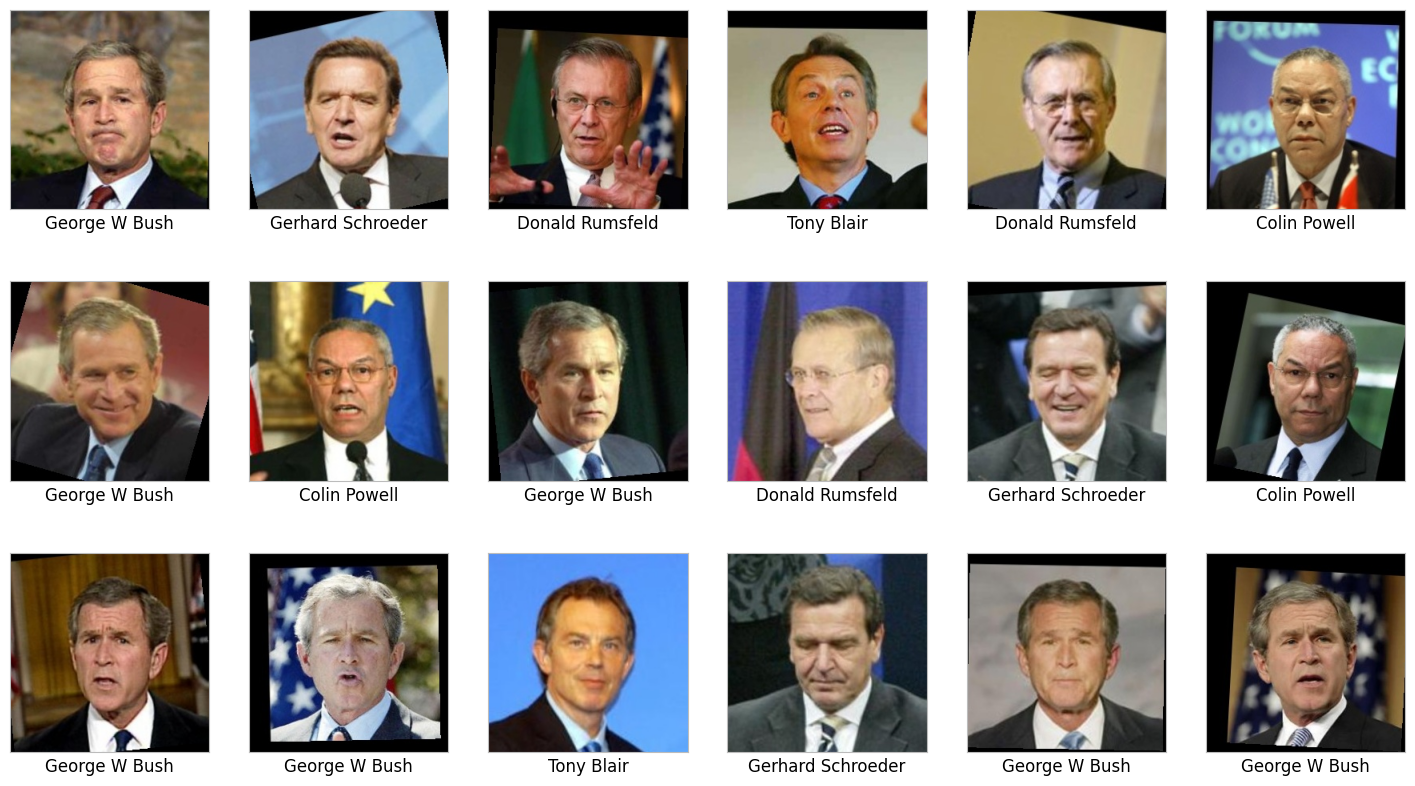

In [8]:
import matplotlib.pyplot as plt

plt.style.use("bmh")

fig, ax = plt.subplots(3, 6, figsize=(18, 10))

for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i])
    axi.set(xticks=[], yticks=[], xlabel=faces.target_names[faces.target[i]])

In [9]:
import numpy as np

mask = np.zeros(faces.target.shape, dtype=bool)

for target in np.unique(faces.target):
    mask[np.where(faces.target == target)[0][:100]] = 1

X_faces = faces.data[mask]
y_faces = faces.target[mask]
X_faces = np.reshape(
    X_faces,
    (
        X_faces.shape[0],
        faces.images.shape[1],
        faces.images.shape[2],
        faces.images.shape[3],
    ),
)
X_faces.shape

(500, 250, 250, 3)

In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import preprocess_input

face_images = preprocess_input(np.array(X_faces * 255))

X_train, X_test, y_train, y_test = train_test_split(
    face_images, y_faces, train_size=0.8, stratify=y_faces, random_state=0
)

In [17]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(X_train.shape[1:])))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dense(class_count, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [18]:
hist = model.fit(
    X_train / 255,
    y_train,
    validation_data=(X_test / 255, y_test),
    epochs=20,
    batch_size=10,
)

Epoch 1/20
40/40 [==============================] - 6s 153ms/step - loss: 1.9831 - accuracy: 0.2250 - val_loss: 1.5873 - val_accuracy: 0.3600
Epoch 2/20
40/40 [==============================] - 6s 154ms/step - loss: 1.5123 - accuracy: 0.3850 - val_loss: 1.3498 - val_accuracy: 0.5000
Epoch 3/20
40/40 [==============================] - 6s 152ms/step - loss: 1.2208 - accuracy: 0.5050 - val_loss: 1.3498 - val_accuracy: 0.4800
Epoch 4/20
40/40 [==============================] - 6s 153ms/step - loss: 0.8712 - accuracy: 0.6925 - val_loss: 1.0213 - val_accuracy: 0.6500
Epoch 5/20
40/40 [==============================] - 6s 151ms/step - loss: 0.5174 - accuracy: 0.8075 - val_loss: 0.9777 - val_accuracy: 0.6500
Epoch 6/20
40/40 [==============================] - 6s 151ms/step - loss: 0.3518 - accuracy: 0.8725 - val_loss: 0.9804 - val_accuracy: 0.7100
Epoch 7/20
40/40 [==============================] - 6s 153ms/step - loss: 0.1141 - accuracy: 0.9675 - val_loss: 1.0828 - val_accuracy: 0.7200
Epoch 

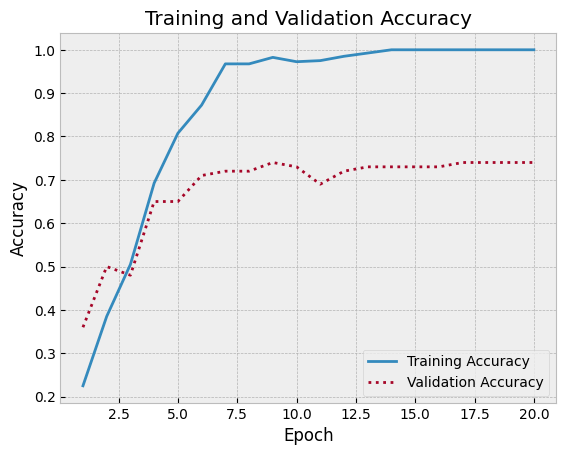

In [19]:
acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]

epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "-", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");

## Transfer Learning

In [20]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights="imagenet", include_top=False)
base_model.trainable = False

94765736/94765736 [==============================] - 5s 0us/step


In [21]:
from tensorflow.keras.layers import Dense, Flatten, Resizing
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Resizing(224, 224))
model.add(base_model)
model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dense(class_count, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

Epoch 1/10
40/40 [==============================] - 15s 329ms/step - loss: 34.3237 - accuracy: 0.4850 - val_loss: 12.2420 - val_accuracy: 0.6600
Epoch 2/10
40/40 [==============================] - 13s 337ms/step - loss: 2.8137 - accuracy: 0.9000 - val_loss: 9.6591 - val_accuracy: 0.7200
Epoch 3/10
40/40 [==============================] - 13s 337ms/step - loss: 0.7390 - accuracy: 0.9475 - val_loss: 9.8677 - val_accuracy: 0.7200
Epoch 4/10
40/40 [==============================] - 13s 328ms/step - loss: 0.2564 - accuracy: 0.9800 - val_loss: 8.6055 - val_accuracy: 0.7300
Epoch 5/10
40/40 [==============================] - 13s 335ms/step - loss: 0.7677 - accuracy: 0.9725 - val_loss: 8.6897 - val_accuracy: 0.7700
Epoch 6/10
40/40 [==============================] - 13s 330ms/step - loss: 0.2957 - accuracy: 0.9825 - val_loss: 8.7229 - val_accuracy: 0.7800
Epoch 7/10
40/40 [==============================] - 14s 340ms/step - loss: 0.3988 - accuracy: 0.9775 - val_loss: 7.3221 - val_accuracy: 0.75

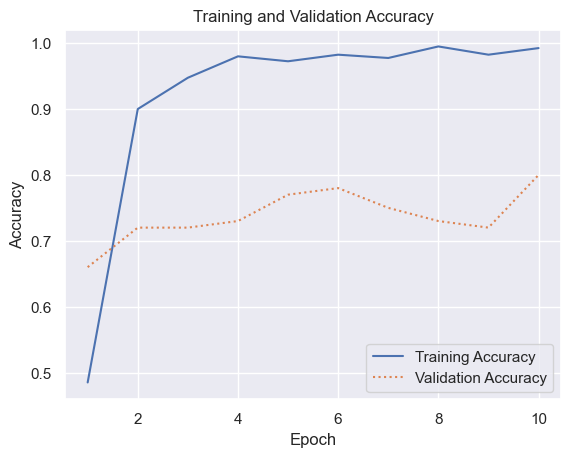

In [22]:
import seaborn as sns

sns.set()

hist = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), batch_size=10, epochs=10
)

acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]

epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "-", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");